In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Install additional visualization packages
!pip install plotly kaleido seaborn

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.8 MB/s eta 0:00:00


In [ ]:
# Extended Neural Network Architectures
class DeepNN(nn.Module):
    """Deep Neural Network with multiple hidden layers"""
    def __init__(self, input_size, num_classes=2):
        super(DeepNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 16)
        self.fc5 = nn.Linear(16, num_classes)
        self.dropout = nn.Dropout(0.3)
        self.batch_norm1 = nn.BatchNorm1d(128)
        self.batch_norm2 = nn.BatchNorm1d(64)
        self.batch_norm3 = nn.BatchNorm1d(32)

    def forward(self, x):
        x = F.relu(self.batch_norm1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm3(self.fc3(x)))
        x = self.dropout(x)
        x = F.relu(self.fc4(x))
        x = self.fc5(x)
        return x

class ConvolutionalNN(nn.Module):
    """1D Convolutional Neural Network for tabular data"""
    def __init__(self, input_size, num_classes=2):
        super(ConvolutionalNN, self).__init__()
        self.reshape_size = int(np.sqrt(input_size)) + 1
        padding_needed = self.reshape_size ** 2 - input_size
        self.padding_needed = padding_needed

        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.25)

        # Calculate the size after convolutions
        conv_output_size = 64 * (self.reshape_size ** 2 // 4)
        self.fc1 = nn.Linear(conv_output_size, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Pad input to make it square-reshapeable
        if self.padding_needed > 0:
            padding = torch.zeros(x.size(0), self.padding_needed).to(x.device)
            x = torch.cat([x, padding], dim=1)

        # Reshape for 1D convolution
        x = x.unsqueeze(1)  # Add channel dimension
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)

        # Flatten for fully connected layers
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class AttentionNN(nn.Module):
    """Neural Network with attention mechanism"""
    def __init__(self, input_size, num_classes=2):
        super(AttentionNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = 64

        self.fc1 = nn.Linear(input_size, self.hidden_size)
        self.attention = nn.Linear(self.hidden_size, 1)
        self.fc2 = nn.Linear(self.hidden_size, num_classes)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # Feature transformation
        h = F.relu(self.fc1(x))

        # Attention mechanism
        attention_weights = F.softmax(self.attention(h), dim=1)
        attended_features = h * attention_weights

        # Output layer
        x = self.dropout(attended_features)
        x = self.fc2(x)
        return x

# Enhanced ProxyFL Client with Multiple Algorithms
class EnhancedProxyFLClient:
    """Enhanced ProxyFL Client with multiple algorithm support"""
    def __init__(self, client_id, client_data, model_type='simple_nn', device='cpu'):
        self.client_id = client_id
        self.device = device
        self.model_type = model_type

        # Client data
        self.X_train = torch.FloatTensor(client_data['X_train']).to(device)
        self.y_train = torch.LongTensor(client_data['y_train']).to(device)

        # Create dataset and dataloader
        self.train_dataset = TensorDataset(self.X_train, self.y_train)
        self.train_loader = DataLoader(self.train_dataset, batch_size=16, shuffle=True)

        input_size = self.X_train.shape[1]
        num_classes = proxy_data_manager.num_classes

        # Initialize models based on type
        self.private_model, self.proxy_model = self._create_models(input_size, num_classes)

        # Optimizers with different learning rates for different models
        lr = self._get_learning_rate()
        self.private_optimizer = optim.Adam(self.private_model.parameters(), lr=lr)
        self.proxy_optimizer = optim.Adam(self.proxy_model.parameters(), lr=lr)

        # Loss function
        self.criterion = nn.CrossEntropyLoss()

        # Training history
        self.training_history = {
            'losses': [],
            'accuracies': [],
            'epochs_completed': 0
        }

    def _create_models(self, input_size, num_classes):
        """Create models based on specified type"""
        model_configs = {
            'linear': lambda: (LinearRegressionNN(input_size, num_classes),
                             LinearRegressionNN(input_size, num_classes)),
            'simple_nn': lambda: (SimpleNN(input_size, num_classes=num_classes),
                                 SimpleNN(input_size, num_classes=num_classes)),
            'deep_nn': lambda: (DeepNN(input_size, num_classes),
                               DeepNN(input_size, num_classes)),
            'conv_nn': lambda: (ConvolutionalNN(input_size, num_classes),
                               ConvolutionalNN(input_size, num_classes)),
            'attention_nn': lambda: (AttentionNN(input_size, num_classes),
                                   AttentionNN(input_size, num_classes))
        }

        if self.model_type in model_configs:
            private_model, proxy_model = model_configs[self.model_type]()
        else:
            private_model, proxy_model = model_configs['simple_nn']()

        return private_model.to(self.device), proxy_model.to(self.device)

    def _get_learning_rate(self):
        """Get appropriate learning rate for model type"""
        lr_config = {
            'linear': 0.01,
            'simple_nn': 0.001,
            'deep_nn': 0.0005,
            'conv_nn': 0.001,
            'attention_nn': 0.001
        }
        return lr_config.get(self.model_type, 0.001)

    def local_training(self, epochs=5, mutual_learning_weight=0.5):
        """Enhanced training with history tracking"""
        self.private_model.train()
        self.proxy_model.train()

        epoch_losses = []

        for epoch in range(epochs):
            batch_losses = []
            for batch_X, batch_y in self.train_loader:
                # Forward pass
                private_output = self.private_model(batch_X)
                proxy_output = self.proxy_model(batch_X)

                # Task-specific loss
                private_task_loss = self.criterion(private_output, batch_y)
                proxy_task_loss = self.criterion(proxy_output, batch_y)

                # Mutual learning loss
                private_soft = F.softmax(private_output, dim=1)
                proxy_soft = F.softmax(proxy_output, dim=1)

                mutual_loss_private = F.kl_div(
                    F.log_softmax(private_output, dim=1),
                    proxy_soft.detach(),
                    reduction='batchmean'
                )
                mutual_loss_proxy = F.kl_div(
                    F.log_softmax(proxy_output, dim=1),
                    private_soft.detach(),
                    reduction='batchmean'
                )

                # Combined loss
                private_loss = private_task_loss + mutual_learning_weight * mutual_loss_private
                proxy_loss = proxy_task_loss + mutual_learning_weight * mutual_loss_proxy

                # Backward pass
                self.private_optimizer.zero_grad()
                private_loss.backward()
                self.private_optimizer.step()

                self.proxy_optimizer.zero_grad()
                proxy_loss.backward()
                self.proxy_optimizer.step()

                batch_losses.append((private_loss.item() + proxy_loss.item()) / 2)

            epoch_loss = np.mean(batch_losses)
            epoch_losses.append(epoch_loss)
            self.training_history['epochs_completed'] += 1

        avg_loss = np.mean(epoch_losses)
        self.training_history['losses'].append(avg_loss)
        return avg_loss

    def get_proxy_model_params(self):
        return copy.deepcopy(self.proxy_model.state_dict())

    def update_proxy_model(self, aggregated_params):
        self.proxy_model.load_state_dict(aggregated_params)

    def evaluate(self, X_test, y_test):
        """Enhanced evaluation with detailed metrics"""
        self.private_model.eval()
        with torch.no_grad():
            X_test_tensor = torch.FloatTensor(X_test).to(self.device)
            outputs = self.private_model(X_test_tensor)
            _, predicted = torch.max(outputs.data, 1)
            predicted_np = predicted.cpu().numpy()

            # Calculate probabilities for ROC analysis
            probabilities = F.softmax(outputs, dim=1).cpu().numpy()

            accuracy = accuracy_score(y_test, predicted_np)
            self.training_history['accuracies'].append(accuracy)

        return accuracy, predicted_np, probabilities


In [ ]:
# Comprehensive Visualization Suite
class FederatedLearningVisualizer:
    """Comprehensive visualization suite for federated learning results"""

    def __init__(self, results, data_manager):
        self.results = results
        self.data_manager = data_manager
        self.colors = plt.cm.Set3(np.linspace(0, 1, len(results)))

    def create_training_convergence_plot(self):
        """Create detailed training convergence visualization"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('ProxyFL Training Convergence Analysis', fontsize=20, fontweight='bold')

        # Loss convergence
        ax1 = axes[0, 0]
        for idx, (model_type, result) in enumerate(self.results.items()):
            rounds = list(range(1, len(result['losses']) + 1))
            ax1.plot(rounds, result['losses'], marker='o', linewidth=3,
                    label=model_type.upper(), color=self.colors[idx])

        ax1.set_title('Training Loss Convergence', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Communication Round')
        ax1.set_ylabel('Average Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Accuracy convergence
        ax2 = axes[0, 1]
        for idx, (model_type, result) in enumerate(self.results.items()):
            rounds = list(range(1, len(result['accuracies']) + 1))
            ax2.plot(rounds, result['accuracies'], marker='s', linewidth=3,
                    label=model_type.upper(), color=self.colors[idx])

        ax2.set_title('Accuracy Convergence', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Communication Round')
        ax2.set_ylabel('Average Accuracy')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Model comparison bar chart
        ax3 = axes[1, 0]
        model_names = list(self.results.keys())
        final_accuracies = [result['accuracies'][-1] for result in self.results.values()]

        bars = ax3.bar(model_names, final_accuracies, color=self.colors[:len(model_names)])
        ax3.set_title('Final Model Performance Comparison', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Final Accuracy')
        ax3.set_ylim(0, 1)

        # Add value labels on bars
        for bar, acc in zip(bars, final_accuracies):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

        # Learning rate analysis
        ax4 = axes[1, 1]
        improvement_rates = []
        for model_type, result in self.results.items():
            if len(result['accuracies']) > 1:
                initial_acc = result['accuracies'][0]
                final_acc = result['accuracies'][-1]
                improvement = (final_acc - initial_acc) / len(result['accuracies'])
                improvement_rates.append(improvement)
            else:
                improvement_rates.append(0)

        bars = ax4.bar(model_names, improvement_rates, color=self.colors[:len(model_names)])
        ax4.set_title('Learning Rate Analysis', fontsize=14, fontweight='bold')
        ax4.set_ylabel('Accuracy Improvement per Round')

        plt.tight_layout()
        plt.show()

    def create_confusion_matrices(self):
        """Create confusion matrices for all models"""
        n_models = len(self.results)
        fig, axes = plt.subplots(2, (n_models + 1) // 2, figsize=(5 * ((n_models + 1) // 2), 10))
        if n_models == 1:
            axes = [axes]
        elif n_models <= 2:
            axes = axes.flatten()
        else:
            axes = axes.flatten()

        fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

        X_test, y_test = self.data_manager.X_test_global, self.data_manager.y_test_global

        for idx, (model_type, result) in enumerate(self.results.items()):
            # Get predictions from the first client (representative)
            client = result['clients'][0]
            _, predictions, _ = client.evaluate(X_test, y_test)

            # Create confusion matrix
            cm = confusion_matrix(y_test, predictions)

            # Plot
            ax = axes[idx] if n_models > 1 else axes
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                       square=True, cbar_kws={'shrink': 0.8})
            ax.set_title(f'{model_type.upper()} Confusion Matrix', fontweight='bold')
            ax.set_xlabel('Predicted Label')
            ax.set_ylabel('True Label')

        # Hide unused subplots
        for idx in range(n_models, len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()

    def create_client_performance_heatmap(self):
        """Create heatmap showing performance across clients and rounds"""
        fig, axes = plt.subplots(1, len(self.results), figsize=(6 * len(self.results), 6))
        if len(self.results) == 1:
            axes = [axes]

        fig.suptitle('Client Performance Heatmap Across Training Rounds',
                    fontsize=16, fontweight='bold')

        X_test, y_test = self.data_manager.X_test_global, self.data_manager.y_test_global

        for idx, (model_type, result) in enumerate(self.results.items()):
            # Simulate client performance across rounds
            clients = result['clients']
            rounds = len(result['accuracies'])

            # Create performance matrix
            performance_matrix = np.zeros((len(clients), rounds))

            for round_idx in range(rounds):
                for client_idx, client in enumerate(clients):
                    accuracy, _, _ = client.evaluate(X_test, y_test)
                    performance_matrix[client_idx, round_idx] = accuracy

            # Plot heatmap
            ax = axes[idx] if len(self.results) > 1 else axes[0]
            im = ax.imshow(performance_matrix, cmap='RdYlGn', aspect='auto')

            ax.set_title(f'{model_type.upper()} Client Performance', fontweight='bold')
            ax.set_xlabel('Training Round')
            ax.set_ylabel('Client ID')
            ax.set_xticks(range(rounds))
            ax.set_xticklabels([f'R{i+1}' for i in range(rounds)])
            ax.set_yticks(range(len(clients)))
            ax.set_yticklabels([f'C{i}' for i in range(len(clients))])

            # Add colorbar
            plt.colorbar(im, ax=ax, label='Accuracy')

            # Add text annotations
            for i in range(len(clients)):
                for j in range(rounds):
                    ax.text(j, i, f'{performance_matrix[i, j]:.2f}',
                           ha='center', va='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

    def create_interactive_dashboard(self):
        """Create interactive Plotly dashboard"""
        # Prepare data for interactive plots
        rounds_data = []
        for model_type, result in self.results.items():
            for round_idx, (loss, acc) in enumerate(zip(result['losses'], result['accuracies'])):
                rounds_data.append({
                    'Model': model_type.upper(),
                    'Round': round_idx + 1,
                    'Loss': loss,
                    'Accuracy': acc
                })

        df_rounds = pd.DataFrame(rounds_data)

        # Create subplots
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=('Training Loss Over Time', 'Accuracy Over Time',
                          'Final Performance Comparison', 'Model Complexity Analysis'),
            specs=[[{"secondary_y": False}, {"secondary_y": False}],
                   [{"secondary_y": False}, {"secondary_y": False}]]
        )

        # Loss over time
        for model_type in df_rounds['Model'].unique():
            model_data = df_rounds[df_rounds['Model'] == model_type]
            fig.add_trace(
                go.Scatter(x=model_data['Round'], y=model_data['Loss'],
                          mode='lines+markers', name=f'{model_type} Loss',
                          line=dict(width=3)),
                row=1, col=1
            )

        # Accuracy over time
        for model_type in df_rounds['Model'].unique():
            model_data = df_rounds[df_rounds['Model'] == model_type]
            fig.add_trace(
                go.Scatter(x=model_data['Round'], y=model_data['Accuracy'],
                          mode='lines+markers', name=f'{model_type} Accuracy',
                          line=dict(width=3)),
                row=1, col=2
            )

        # Final performance comparison
        final_performance = df_rounds.groupby('Model')['Accuracy'].last().reset_index()
        fig.add_trace(
            go.Bar(x=final_performance['Model'], y=final_performance['Accuracy'],
                   name='Final Accuracy',
                   marker_color='lightblue'),
            row=2, col=1
        )

        # Model complexity (number of parameters estimation)
        model_complexity = {
            'LINEAR': 1,
            'SIMPLE_NN': 2,
            'DEEP_NN': 4,
            'CONV_NN': 3,
            'ATTENTION_NN': 3
        }

        complexity_data = []
        for model_type, result in self.results.items():
            complexity_data.append({
                'Model': model_type.upper(),
                'Complexity': model_complexity.get(model_type.upper(), 2),
                'Accuracy': result['accuracies'][-1]
            })

        df_complexity = pd.DataFrame(complexity_data)
        fig.add_trace(
            go.Scatter(x=df_complexity['Complexity'], y=df_complexity['Accuracy'],
                      mode='markers+text', text=df_complexity['Model'],
                      textposition='top center',
                      marker=dict(size=15, color='red'),
                      name='Complexity vs Accuracy'),
            row=2, col=2
        )

        # Update layout
        fig.update_layout(height=800, showlegend=True,
                         title_text="ProxyFL Interactive Performance Dashboard")
        fig.update_xaxes(title_text="Round", row=1, col=1)
        fig.update_xaxes(title_text="Round", row=1, col=2)
        fig.update_xaxes(title_text="Model", row=2, col=1)
        fig.update_xaxes(title_text="Model Complexity", row=2, col=2)
        fig.update_yaxes(title_text="Loss", row=1, col=1)
        fig.update_yaxes(title_text="Accuracy", row=1, col=2)
        fig.update_yaxes(title_text="Accuracy", row=2, col=1)
        fig.update_yaxes(title_text="Accuracy", row=2, col=2)

        fig.show()

    def create_comprehensive_report(self):
        """Generate comprehensive visual report"""
        print("Generating Comprehensive ProxyFL Analysis Report...")
        print("="*60)

        # Create all visualizations
        self.create_training_convergence_plot()
        self.create_confusion_matrices()
        self.create_client_performance_heatmap()
        self.create_interactive_dashboard()

        # Print summary statistics
        print("\nPERFORMANCE SUMMARY")
        print("="*60)
        for model_type, result in self.results.items():
            print(f"\n{model_type.upper()}:")
            print(f"  • Final Accuracy: {result['accuracies'][-1]:.4f}")
            print(f"  • Best Accuracy: {max(result['accuracies']):.4f}")
            print(f"  • Final Loss: {result['losses'][-1]:.4f}")
            print(f"  • Training Rounds: {len(result['accuracies'])}")
            print(f"  • Convergence Rate: {(result['accuracies'][-1] - result['accuracies'][0])/len(result['accuracies']):.4f} per round")


 Starting Enhanced ProxyFL Simulation with Multiple Algorithms...

 Running ProxyFL with LINEAR
Using device: cpu

--- Round 1 ---
Average training loss: 0.7359
Round 1 - Avg Accuracy: 0.6370
Client Accuracies: ['0.6852', '0.4630', '0.7778', '0.5000', '0.7593']

--- Round 2 ---
Average training loss: 0.5388
Round 2 - Avg Accuracy: 0.6852
Client Accuracies: ['0.7778', '0.4815', '0.7593', '0.6296', '0.7778']

--- Round 3 ---
Average training loss: 0.4604
Round 3 - Avg Accuracy: 0.7111
Client Accuracies: ['0.7963', '0.5185', '0.7963', '0.6852', '0.7593']

--- Round 4 ---
Average training loss: 0.4107
Round 4 - Avg Accuracy: 0.7519
Client Accuracies: ['0.8519', '0.5926', '0.8148', '0.7407', '0.7593']

--- Round 5 ---
Average training loss: 0.3833
Round 5 - Avg Accuracy: 0.7630
Client Accuracies: ['0.8519', '0.6111', '0.8704', '0.7222', '0.7593']

--- Round 6 ---
Average training loss: 0.3589
Round 6 - Avg Accuracy: 0.7815
Client Accuracies: ['0.8519', '0.6296', '0.8704', '0.7407', '0.8148'

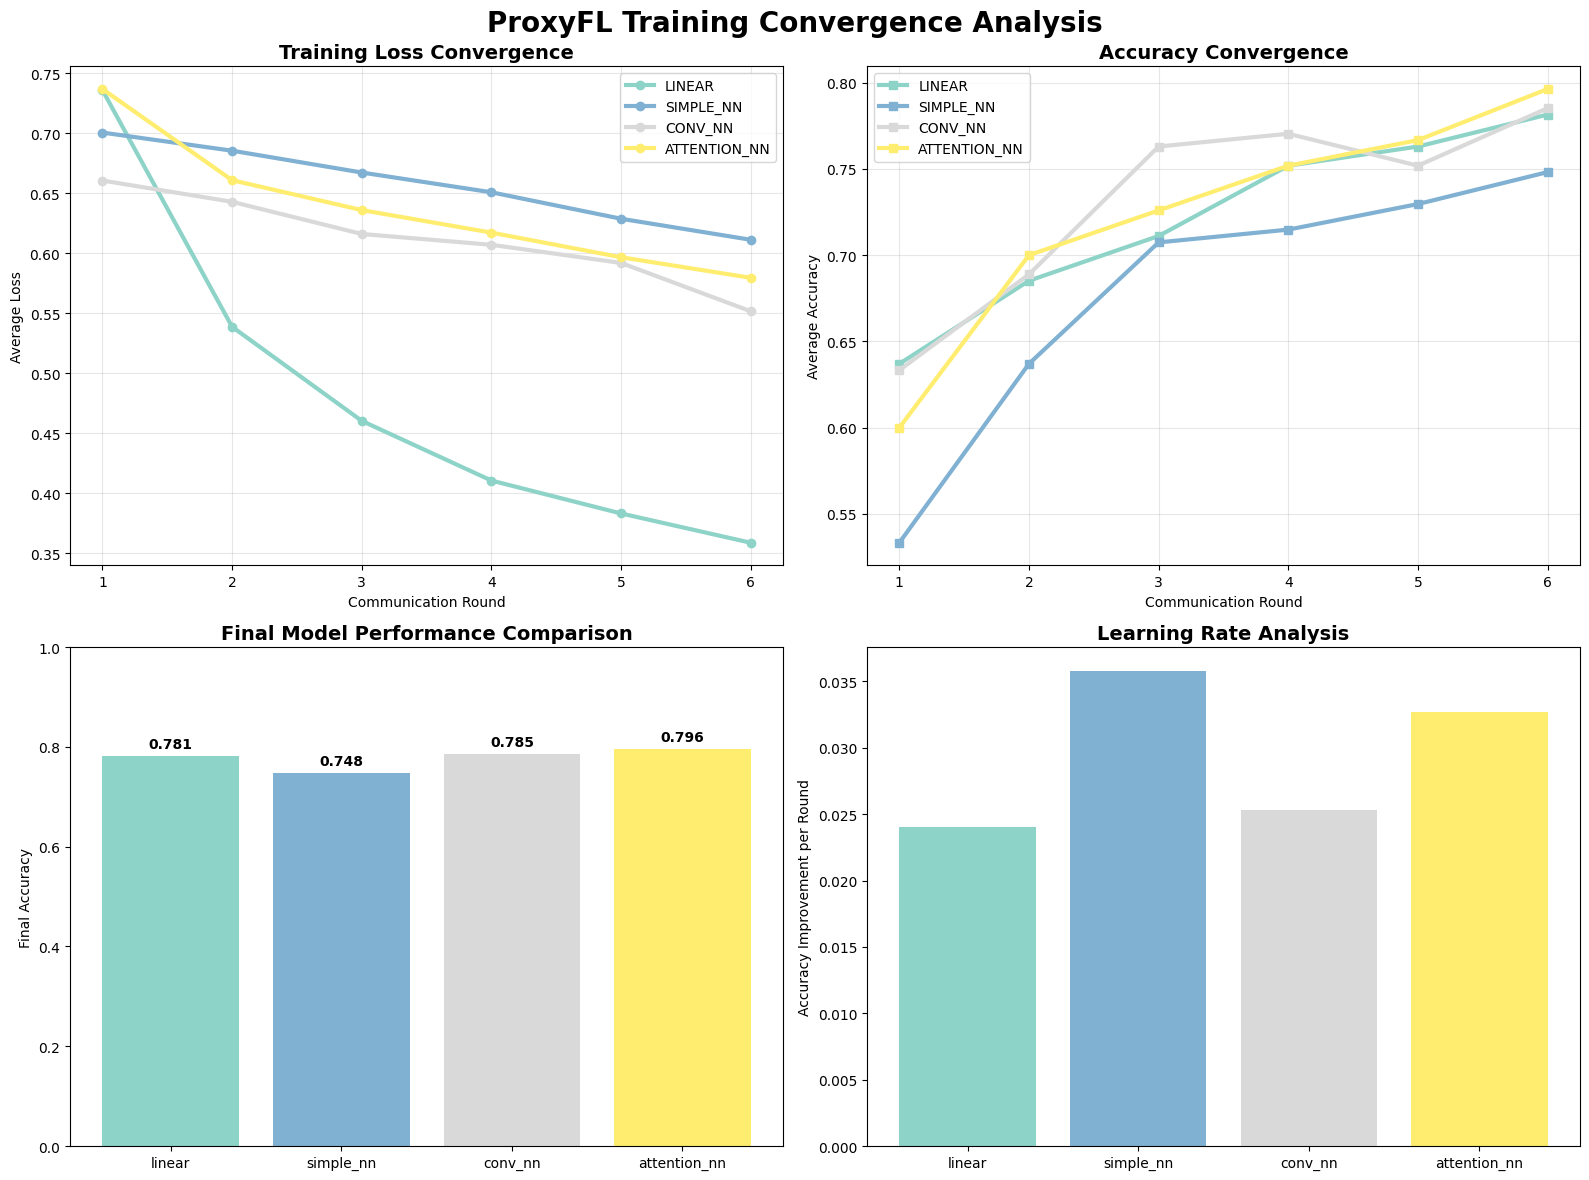

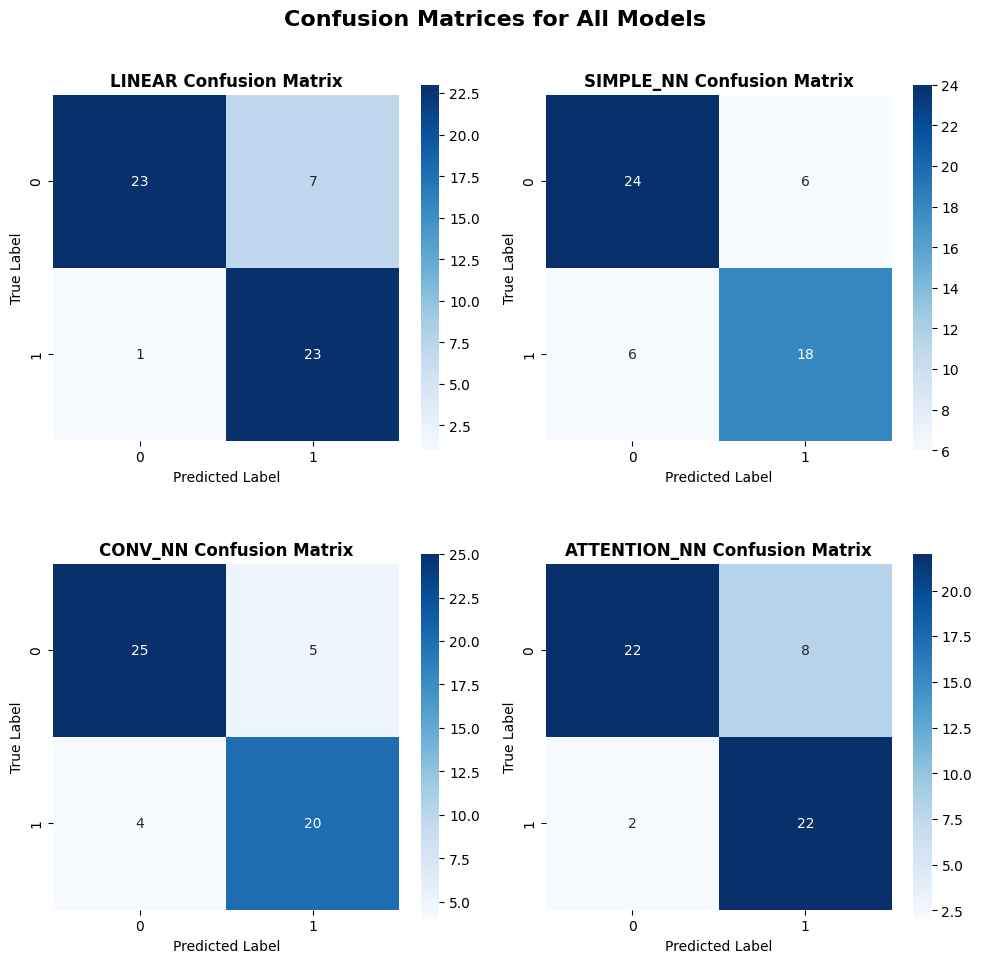

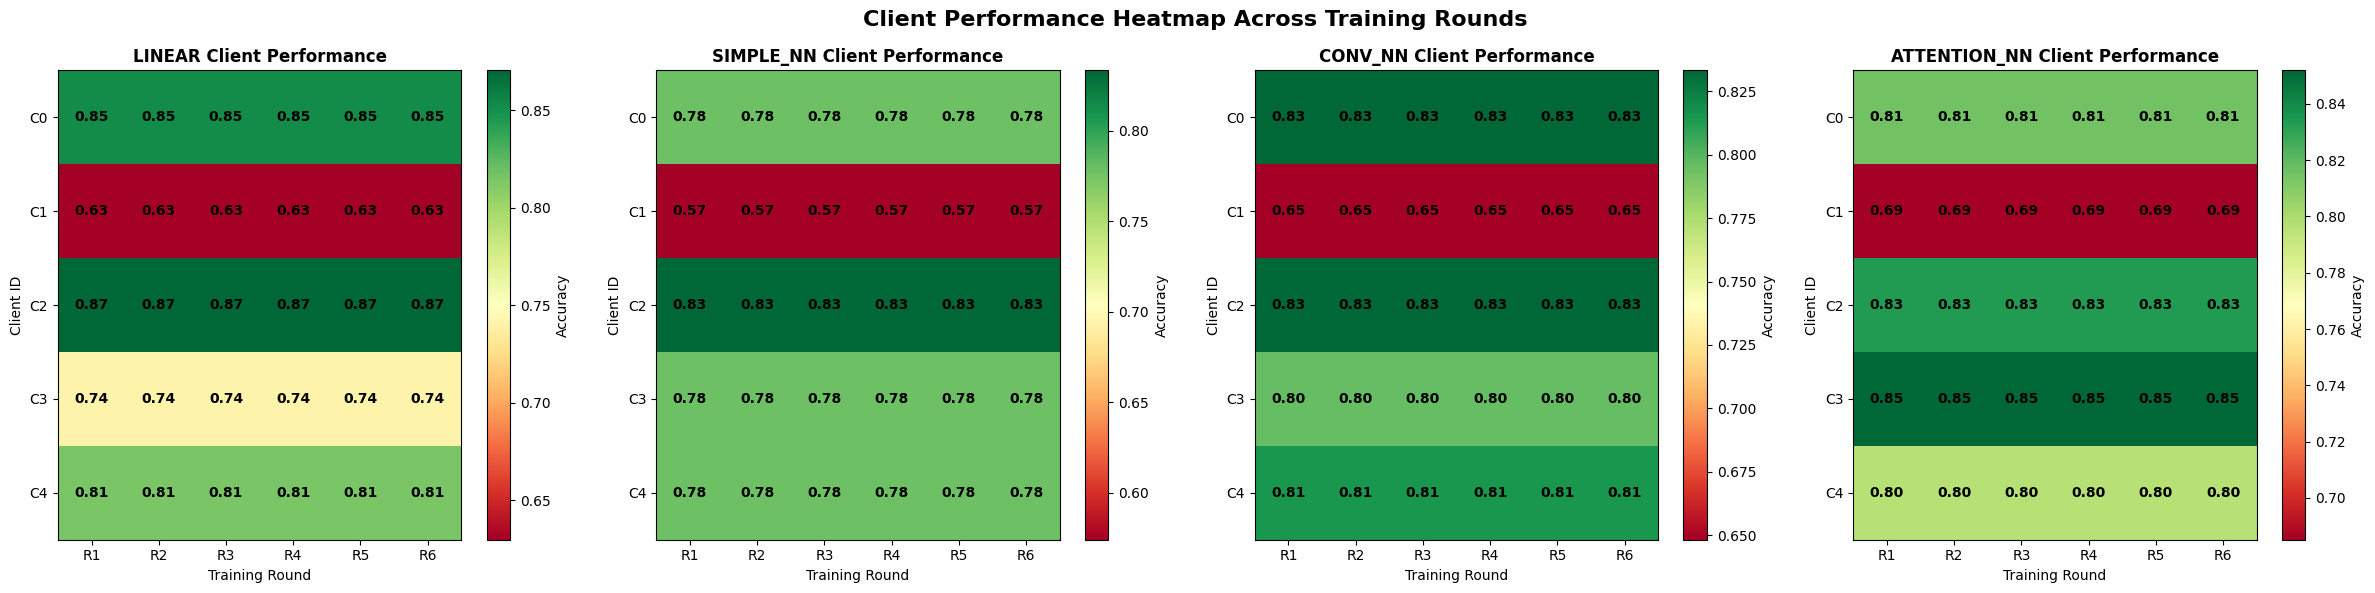


PERFORMANCE SUMMARY

LINEAR:
  • Final Accuracy: 0.7815
  • Best Accuracy: 0.7815
  • Final Loss: 0.3589
  • Training Rounds: 6
  • Convergence Rate: 0.0241 per round

SIMPLE_NN:
  • Final Accuracy: 0.7481
  • Best Accuracy: 0.7481
  • Final Loss: 0.6113
  • Training Rounds: 6
  • Convergence Rate: 0.0358 per round

CONV_NN:
  • Final Accuracy: 0.7852
  • Best Accuracy: 0.7852
  • Final Loss: 0.5517
  • Training Rounds: 6
  • Convergence Rate: 0.0253 per round

ATTENTION_NN:
  • Final Accuracy: 0.7963
  • Best Accuracy: 0.7963
  • Final Loss: 0.5796
  • Training Rounds: 6
  • Convergence Rate: 0.0327 per round


In [ ]:
# Run Enhanced ProxyFL Simulation with Multiple Algorithms
def run_enhanced_proxyfl_simulation():
    """Run enhanced ProxyFL simulation with multiple algorithms"""

    # Enhanced algorithm list
    algorithms = ['linear', 'simple_nn', 'deep_nn', 'conv_nn', 'attention_nn']
    enhanced_results = {}

    for algorithm in algorithms:
        print(f"\n{'='*50}")
        print(f" Running ProxyFL with {algorithm.upper()}")
        print(f"{'='*50}")

        try:
            # Create enhanced clients
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            print(f"Using device: {device}")

            clients = []
            for i, client_data in enumerate(proxy_data_manager.client_datasets):
                client = EnhancedProxyFLClient(i, client_data, algorithm, device)
                clients.append(client)

            # Enhanced coordinator with better aggregation
            class EnhancedCoordinator:
                def __init__(self, clients):
                    self.clients = clients
                    self.round_history = []

                def aggregate_proxy_models(self):
                    proxy_params_list = [client.get_proxy_model_params() for client in self.clients]
                    aggregated_params = copy.deepcopy(proxy_params_list[0])

                    for key in aggregated_params.keys():
                        aggregated_params[key] = torch.zeros_like(aggregated_params[key])
                        for client_params in proxy_params_list:
                            aggregated_params[key] += client_params[key]
                        aggregated_params[key] /= len(proxy_params_list)

                    return aggregated_params

                def train_round(self, round_num, local_epochs=3):
                    print(f"\n--- Round {round_num} ---")

                    round_losses = []
                    for client in self.clients:
                        loss = client.local_training(epochs=local_epochs)
                        round_losses.append(loss)

                    # Aggregate and update
                    aggregated_proxy_params = self.aggregate_proxy_models()
                    for client in self.clients:
                        client.update_proxy_model(aggregated_proxy_params)

                    avg_loss = np.mean(round_losses)
                    self.round_history.append({
                        'round': round_num,
                        'avg_loss': avg_loss,
                        'client_losses': round_losses
                    })

                    print(f"Average training loss: {avg_loss:.4f}")
                    return avg_loss

                def evaluate_all_clients(self, X_test, y_test):
                    accuracies = []
                    predictions_list = []
                    probabilities_list = []

                    for client in self.clients:
                        accuracy, predictions, probabilities = client.evaluate(X_test, y_test)
                        accuracies.append(accuracy)
                        predictions_list.append(predictions)
                        probabilities_list.append(probabilities)

                    return np.mean(accuracies), accuracies, predictions_list, probabilities_list

            coordinator = EnhancedCoordinator(clients)

            # Training simulation
            num_rounds = 6
            round_losses = []
            round_accuracies = []

            X_test, y_test = proxy_data_manager.X_test_global, proxy_data_manager.y_test_global

            for round_num in range(1, num_rounds + 1):
                # Training
                avg_loss = coordinator.train_round(round_num, local_epochs=2)
                round_losses.append(avg_loss)

                # Evaluation
                avg_accuracy, client_accuracies, predictions, probabilities = coordinator.evaluate_all_clients(X_test, y_test)
                round_accuracies.append(avg_accuracy)

                print(f"Round {round_num} - Avg Accuracy: {avg_accuracy:.4f}")
                print(f"Client Accuracies: {[f'{acc:.4f}' for acc in client_accuracies]}")

            enhanced_results[algorithm] = {
                'losses': round_losses,
                'accuracies': round_accuracies,
                'clients': clients,
                'coordinator': coordinator,
                'final_predictions': predictions,
                'final_probabilities': probabilities
            }

            print(f" Completed ProxyFL simulation with {algorithm}")

        except Exception as e:
            print(f" Error with {algorithm}: {str(e)}")
            continue

    return enhanced_results

# Execute enhanced simulation
print(" Starting Enhanced ProxyFL Simulation with Multiple Algorithms...")
enhanced_results = run_enhanced_proxyfl_simulation()

# Create comprehensive visualizations
if enhanced_results:
    print("\n Creating Comprehensive Visualizations...")
    visualizer = FederatedLearningVisualizer(enhanced_results, proxy_data_manager)
    visualizer.create_comprehensive_report()
else:
    print(" No results to visualize. Please check for errors.")
